# Notebook 1 — Data Overview

**Goal:** Load the CSV files from the pipeline, understand what the data looks like, check for missing values, and visualize the distributions.

This notebook explores the output of the robocode-autopilot pipeline — CSV files generated from battle recordings. We have three types of files:

- **ticks.csv** — One row per game tick (like a frame in a video). Each row records what the robot could observe at that moment: distances, velocities, angles, energy levels.
- **waves.csv** — One row per bullet fired. Records bullet power, speed, and the distance at which it was fired.
- **scores.csv** — One row per round. Records damage dealt/received, hit rates, and who won.

> **What is a DataFrame?** Think of it like a spreadsheet. Rows are observations (one per game tick), columns are measurements (features like distance, velocity, etc.). pandas is the Python library that gives us these spreadsheet-like tools.

In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# --- Find and load all CSV files ---
CSV_ROOT = Path("../output/csv")

# Discover all CSV files and extract battle_id + robot_name from folder structure
def load_all_csvs(filename):
    """Load all CSV files of a given name (e.g. 'ticks.csv') across all battles and robots."""
    frames = []
    for csv_path in sorted(CSV_ROOT.rglob(filename)):
        # Path structure: output/csv/{battle_id}/{robot_name}/{filename}
        robot_name = csv_path.parent.name
        battle_id = csv_path.parent.parent.name
        df = pd.read_csv(csv_path)
        df['robot_name'] = robot_name
        frames.append(df)
    if not frames:
        print(f"⚠ No {filename} files found!")
        return pd.DataFrame()
    combined = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} {filename} files → {combined.shape[0]:,} rows, {combined.shape[1]} columns")
    return combined

ticks = load_all_csvs("ticks.csv")
waves = load_all_csvs("waves.csv")
scores = load_all_csvs("scores.csv")

Loaded 20 ticks.csv files → 266,890 rows, 29 columns
Loaded 20 waves.csv files → 17,067 rows, 10 columns
Loaded 20 scores.csv files → 100 rows, 10 columns


In [2]:
# --- Quick look at each DataFrame ---
print("=" * 60)
print("TICKS.CSV — one row per game tick per robot perspective")
print("=" * 60)
print(f"Shape: {ticks.shape[0]:,} rows × {ticks.shape[1]} columns")
print(f"\nColumn names:\n{list(ticks.columns)}")
print(f"\nData types:\n{ticks.dtypes}")
print(f"\nFirst 3 rows:")
ticks.head(3)

TICKS.CSV — one row per game tick per robot perspective
Shape: 266,890 rows × 29 columns

Column names:
['battle_id', 'round', 'tick', 'scan_available', 'distance', 'bearing_to_opponent_abs', 'opponent_dist_to_wall_min', 'opponent_energy', 'opponent_fired', 'opponent_fire_power', 'our_gun_heat', 'ticks_since_scan', 'opponent_velocity', 'opponent_lateral_velocity', 'opponent_advancing_velocity', 'opponent_heading_delta', 'energy_ratio', 'our_lateral_velocity', 'our_dist_to_wall_min', 'opponent_wall_ahead_distance', 'opponent_inferred_gun_heat', 'opponent_lateral_direction', 'opponent_velocity_delta', 'opponent_is_decelerating', 'opponent_time_since_direction_change', 'opponent_angular_velocity', 'opponent_max_turn_rate', 'distance_norm', 'robot_name']

Data types:
battle_id                                object
round                                     int64
tick                                      int64
scan_available                            int64
distance                          

,battle_id,round,tick,scan_available,distance,bearing_to_opponent_abs,opponent_dist_to_wall_min,opponent_energy,opponent_fired,opponent_fire_power,...,opponent_wall_ahead_distance,opponent_inferred_gun_heat,opponent_lateral_direction,opponent_velocity_delta,opponent_is_decelerating,opponent_time_since_direction_change,opponent_angular_velocity,opponent_max_turn_rate,distance_norm,robot_name
0,0a24decd,0,0,1,517.438,1.1851,72.032,100.0,0.0,0.0,...,618.351,3.0,0.0,NaN,0.0,1.0,0.000000,0.1745,0.5174,Saguaro 0.1
1,0a24decd,0,1,1,517.438,1.1851,72.032,100.0,0.0,0.0,...,714.252,2.9,0.0,0.0,0.0,2.0,0.000000,0.1745,0.5174,Saguaro 0.1
2,0a24decd,0,2,1,516.604,1.1862,72.856,100.0,0.0,0.0,...,617.351,2.8,1.0,1.0,0.0,3.0,0.001069,0.1614,0.5166,Saguaro 0.1


In [3]:
print("=" * 60)
print("WAVES.CSV — one row per bullet fired")
print("=" * 60)
print(f"Shape: {waves.shape[0]:,} rows × {waves.shape[1]} columns")
print(f"\nColumn names:\n{list(waves.columns)}")
display(waves.head(3))

print("\n" + "=" * 60)
print("SCORES.CSV — one row per round")
print("=" * 60)
print(f"Shape: {scores.shape[0]:,} rows × {scores.shape[1]} columns")
print(f"\nColumn names:\n{list(scores.columns)}")
display(scores.head(3))

WAVES.CSV — one row per bullet fired
Shape: 17,067 rows × 10 columns

Column names:
['battle_id', 'round', 'tick', 'wave_bullet_power', 'wave_bullet_speed', 'wave_fire_distance', 'wave_mea', 'wave_flight_time', 'wave_lateral_velocity_at_fire', 'robot_name']


,battle_id,round,tick,wave_bullet_power,wave_bullet_speed,wave_fire_distance,wave_mea,wave_flight_time,wave_lateral_velocity_at_fire,robot_name
0,0a24decd,0,32,0.15,19.55,504.394,0.421585,25.80,-0.0,Saguaro 0.1
1,0a24decd,0,43,0.15,19.55,504.355,0.421585,25.80,-0.0,Saguaro 0.1
2,0a24decd,0,54,0.15,19.55,503.928,0.421585,25.78,-0.0,Saguaro 0.1



SCORES.CSV — one row per round
Shape: 100 rows × 10 columns

Column names:
['battle_id', 'round', 'ticks_in_round', 'damage_dealt', 'damage_received', 'net_damage', 'our_hit_rate', 'opponent_hit_rate', 'win_rate', 'robot_name']


,battle_id,round,ticks_in_round,damage_dealt,damage_received,net_damage,our_hit_rate,opponent_hit_rate,win_rate,robot_name
0,0a24decd,0,579,0.00,87.0,-87.00,0.0000,0.5217,0.0,Saguaro 0.1
1,0a24decd,1,1523,39.88,13.7,26.18,0.0735,0.0676,0.0,Saguaro 0.1
2,0a24decd,2,1177,53.77,32.7,21.07,0.0896,0.2881,0.0,Saguaro 0.1


## Section 2 — Data Quality: Missing Values

**What is NaN?** NaN stands for "Not a Number." In our data, it means the robot's radar
didn't scan the opponent on that tick, so we don't know the opponent's position, velocity, etc.

Think of it like trying to see someone in a dark room with a flashlight. When your flashlight
(radar) sweeps past them, you see everything. When it doesn't, you see nothing — that's NaN.

We need to know:
- **How much data is missing?** (percentage per column)
- **Which columns have missing data?** (only opponent-related ones should)
- **Are there any duplicate rows?** (there shouldn't be)

Columns with missing values (ticks.csv):
                                      missing_count  missing_pct
distance                                      15683          5.9
bearing_to_opponent_abs                       15683          5.9
opponent_dist_to_wall_min                     15683          5.9
opponent_energy                               15683          5.9
opponent_fired                                15683          5.9
opponent_fire_power                           15683          5.9
opponent_velocity                             15683          5.9
opponent_lateral_velocity                     15683          5.9
opponent_advancing_velocity                   15683          5.9
opponent_heading_delta                        15783          5.9
energy_ratio                                  15683          5.9
our_lateral_velocity                          15683          5.9
our_dist_to_wall_min                          15683          5.9
opponent_wall_ahead_distance                  156

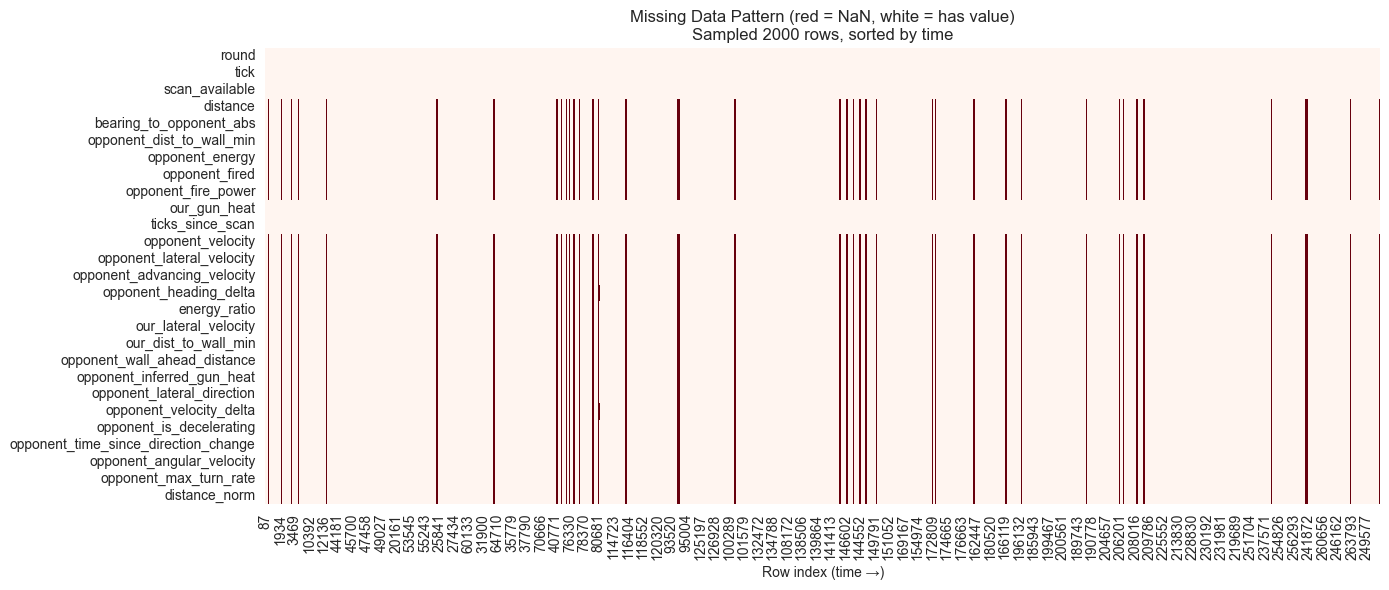


Duplicate rows in ticks.csv: 0


In [4]:
# --- Missing values analysis ---
nan_counts = ticks.isnull().sum()
nan_pct = (ticks.isnull().sum() / len(ticks) * 100).round(1)
nan_summary = pd.DataFrame({'missing_count': nan_counts, 'missing_pct': nan_pct})
nan_summary = nan_summary[nan_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print("Columns with missing values (ticks.csv):")
print(nan_summary.to_string())

# Heatmap of missing data pattern (sample 2000 rows for readability)
fig, ax = plt.subplots(figsize=(14, 6))
sample = ticks.sample(min(2000, len(ticks)), random_state=42).sort_values(['battle_id', 'round', 'tick'])
sns.heatmap(sample.select_dtypes(include=[np.number]).isnull().T, 
            cbar=False, yticklabels=True, cmap='Reds', ax=ax)
ax.set_title("Missing Data Pattern (red = NaN, white = has value)\nSampled 2000 rows, sorted by time")
ax.set_xlabel("Row index (time →)")
plt.tight_layout()
plt.show()

# Duplicates check
dups = ticks.duplicated().sum()
print(f"\nDuplicate rows in ticks.csv: {dups}")

## Section 3 — Descriptive Statistics

Here's what each number in `.describe()` means:

| Statistic | What it means | Analogy |
|-----------|---------------|---------|
| **count** | How many non-NaN values | How many times we actually measured this |
| **mean** | Sum of all values ÷ count. The "average" | If you split all the pizza equally, how much each person gets |
| **std** | Standard deviation — how spread out values are from the mean | Small std = everyone got similar amounts. Large std = some got a lot, some got little |
| **min** | Smallest value | The shortest kid in class |
| **25%** | 25th percentile — 25% of values are below this | A quarter of the class is shorter than this |
| **50%** | Median — the middle value when sorted. Not fooled by extremes | The kid right in the middle of the line when sorted by height |
| **75%** | 75th percentile — 75% of values are below this | Three quarters of the class is shorter than this |
| **max** | Largest value | The tallest kid in class |

The range between 25% and 75% is called the **IQR (Interquartile Range)** — it's the "middle half" of the data.

In [5]:
# --- Descriptive statistics for ticks.csv ---
print("TICKS.CSV — Descriptive Statistics")
print("=" * 60)
# Transpose so features are rows (easier to read with many columns)
display(ticks.describe().T.round(3))

print("\n\nWAVES.CSV — Descriptive Statistics")
print("=" * 60)
display(waves.describe().T.round(3))

print("\n\nSCORES.CSV — Descriptive Statistics")
print("=" * 60)
display(scores.describe().T.round(3))

TICKS.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,266890.0,2.201,1.342,0.000,1.000,2.000,3.000,4.000
tick,266890.0,2242.993,1842.152,0.000,699.000,1803.000,3287.000,7848.000
scan_available,266890.0,0.941,0.235,0.000,1.000,1.000,1.000,1.000
distance,251207.0,521.898,73.398,40.880,489.589,521.829,562.114,830.339
bearing_to_opponent_abs,251207.0,3.125,1.749,0.000,1.543,3.142,4.684,6.283
opponent_dist_to_wall_min,251207.0,93.802,65.126,18.000,39.547,78.729,134.643,299.984
opponent_energy,251207.0,46.013,28.956,0.000,21.654,42.500,69.700,122.850
opponent_fired,251207.0,0.068,0.252,0.000,0.000,0.000,0.000,1.000
opponent_fire_power,251207.0,0.028,0.194,0.000,0.000,0.000,0.000,3.000
our_gun_heat,266890.0,0.448,0.371,0.000,0.120,0.420,0.720,3.000




WAVES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,17067.0,2.210,1.334,0.000,1.000,2.000,3.000,4.000
tick,17067.0,2334.351,1858.006,10.000,729.500,1831.000,3692.500,7694.000
wave_bullet_power,17067.0,0.407,0.633,0.100,0.100,0.150,0.180,3.000
wave_bullet_speed,17067.0,18.779,1.899,11.000,19.475,19.550,19.700,19.700
wave_fire_distance,17067.0,529.588,67.091,40.880,493.232,527.392,571.175,830.339
wave_mea,17067.0,0.448,0.068,0.418,0.418,0.422,0.423,0.814
wave_flight_time,17067.0,28.538,5.201,2.300,25.630,27.590,30.490,73.190
wave_lateral_velocity_at_fire,17067.0,-0.024,5.813,-8.000,-5.932,0.000,5.918,8.000




SCORES.CSV — Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
round,100.0,2.000,1.421,0.0,1.000,2.000,3.000,4.000
ticks_in_round,100.0,2668.900,2213.888,453.0,738.000,2026.500,3665.000,7849.000
damage_dealt,100.0,31.470,20.732,0.0,15.250,28.300,39.070,87.000
damage_received,100.0,31.470,20.732,0.0,15.250,28.300,39.070,87.000
net_damage,100.0,-0.000,35.209,-87.0,-16.650,0.000,16.650,87.000
our_hit_rate,100.0,0.101,0.067,0.0,0.072,0.089,0.110,0.480
opponent_hit_rate,100.0,0.122,0.081,0.0,0.076,0.106,0.146,0.522
win_rate,100.0,0.000,0.000,0.0,0.000,0.000,0.000,0.000


## Section 4 — Distributions: Histograms

A **histogram** divides the range of values into bins (buckets), counts how many values fall in each bin, and draws bars. A tall bar means many data points have values in that range.

A **KDE curve** (Kernel Density Estimation) is a smoothed version of the histogram — instead of blocky bars, it draws a smooth curve that shows the overall shape of the distribution.

Things to look for:
- **Bell-shaped (normal):** Values cluster around the middle — most common in nature
- **Skewed:** Values pile up on one side. Right-skewed = long tail to the right
- **Bimodal:** Two peaks — might mean there are two different "modes" of play
- **Uniform:** Flat — values are equally likely across the range

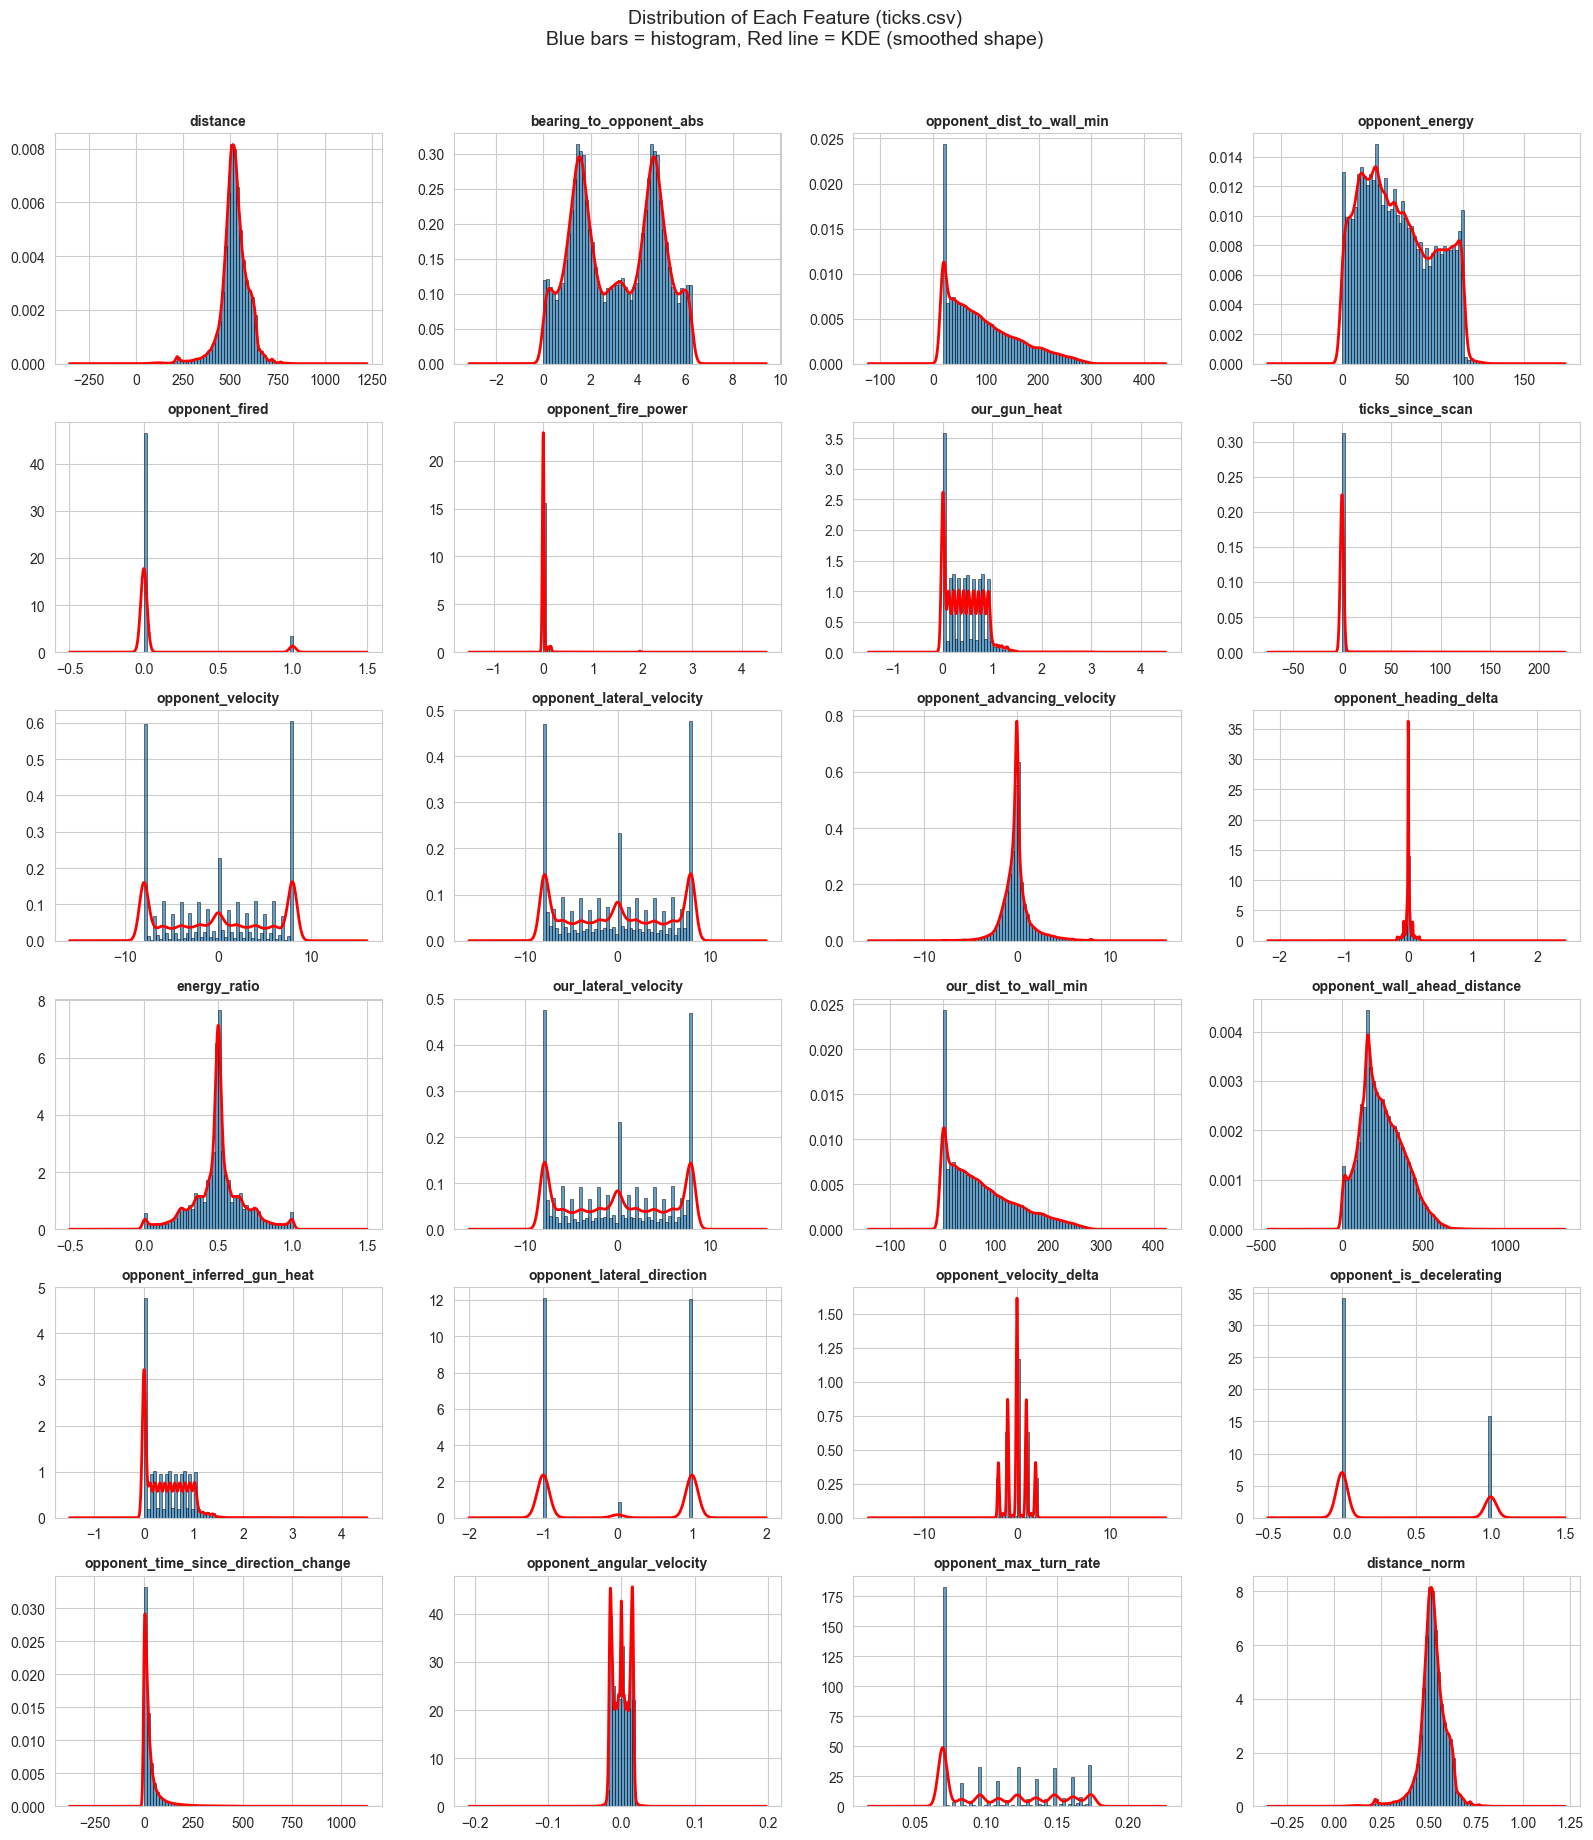

In [6]:
# --- Histograms of all numeric features in ticks.csv ---
# Select only the feature columns (exclude metadata like battle_id, round, tick)
meta_cols = ['battle_id', 'round', 'tick', 'scan_available', 'robot_name']
feature_cols = [c for c in ticks.columns if c not in meta_cols]

n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = ticks[col].dropna()
    if len(data) > 0:
        ax.hist(data, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5, density=True)
        try:
            data.plot.kde(ax=ax, color='red', linewidth=2)
        except Exception:
            pass  # KDE can fail for degenerate distributions
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution of Each Feature (ticks.csv)\nBlue bars = histogram, Red line = KDE (smoothed shape)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Section 5 — Box Plots per Robot

A **box plot** (also called "box and whisker") summarizes a distribution in 5 numbers:

```
         ┌─────────┐
    ─────┤   BOX   ├─────   ●  ●
         └─────────┘
   min  Q1  median  Q3  max  outliers
   (whisker)       (whisker)
```

- **The box** spans from Q1 (25th percentile) to Q3 (75th percentile) — the middle 50% of values
- **The line inside the box** is the median (50th percentile)
- **Whiskers** extend to 1.5 × IQR from the box edges (IQR = Q3 − Q1)
- **Dots beyond the whiskers** are outliers — unusually extreme values

Comparing boxes across robots tells us: does Diamond keep a different distance than BeepBoop? Does DrussGT move laterally more?

C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_76880\1053590135.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax, palette='Set2')
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_76880\1053590135.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_76880\1053590135.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='robot_name', y=col, ax=ax, palette='Set2')
C:\Users\pavelsavara\AppData\Local\Temp\ipykernel_76880\105359

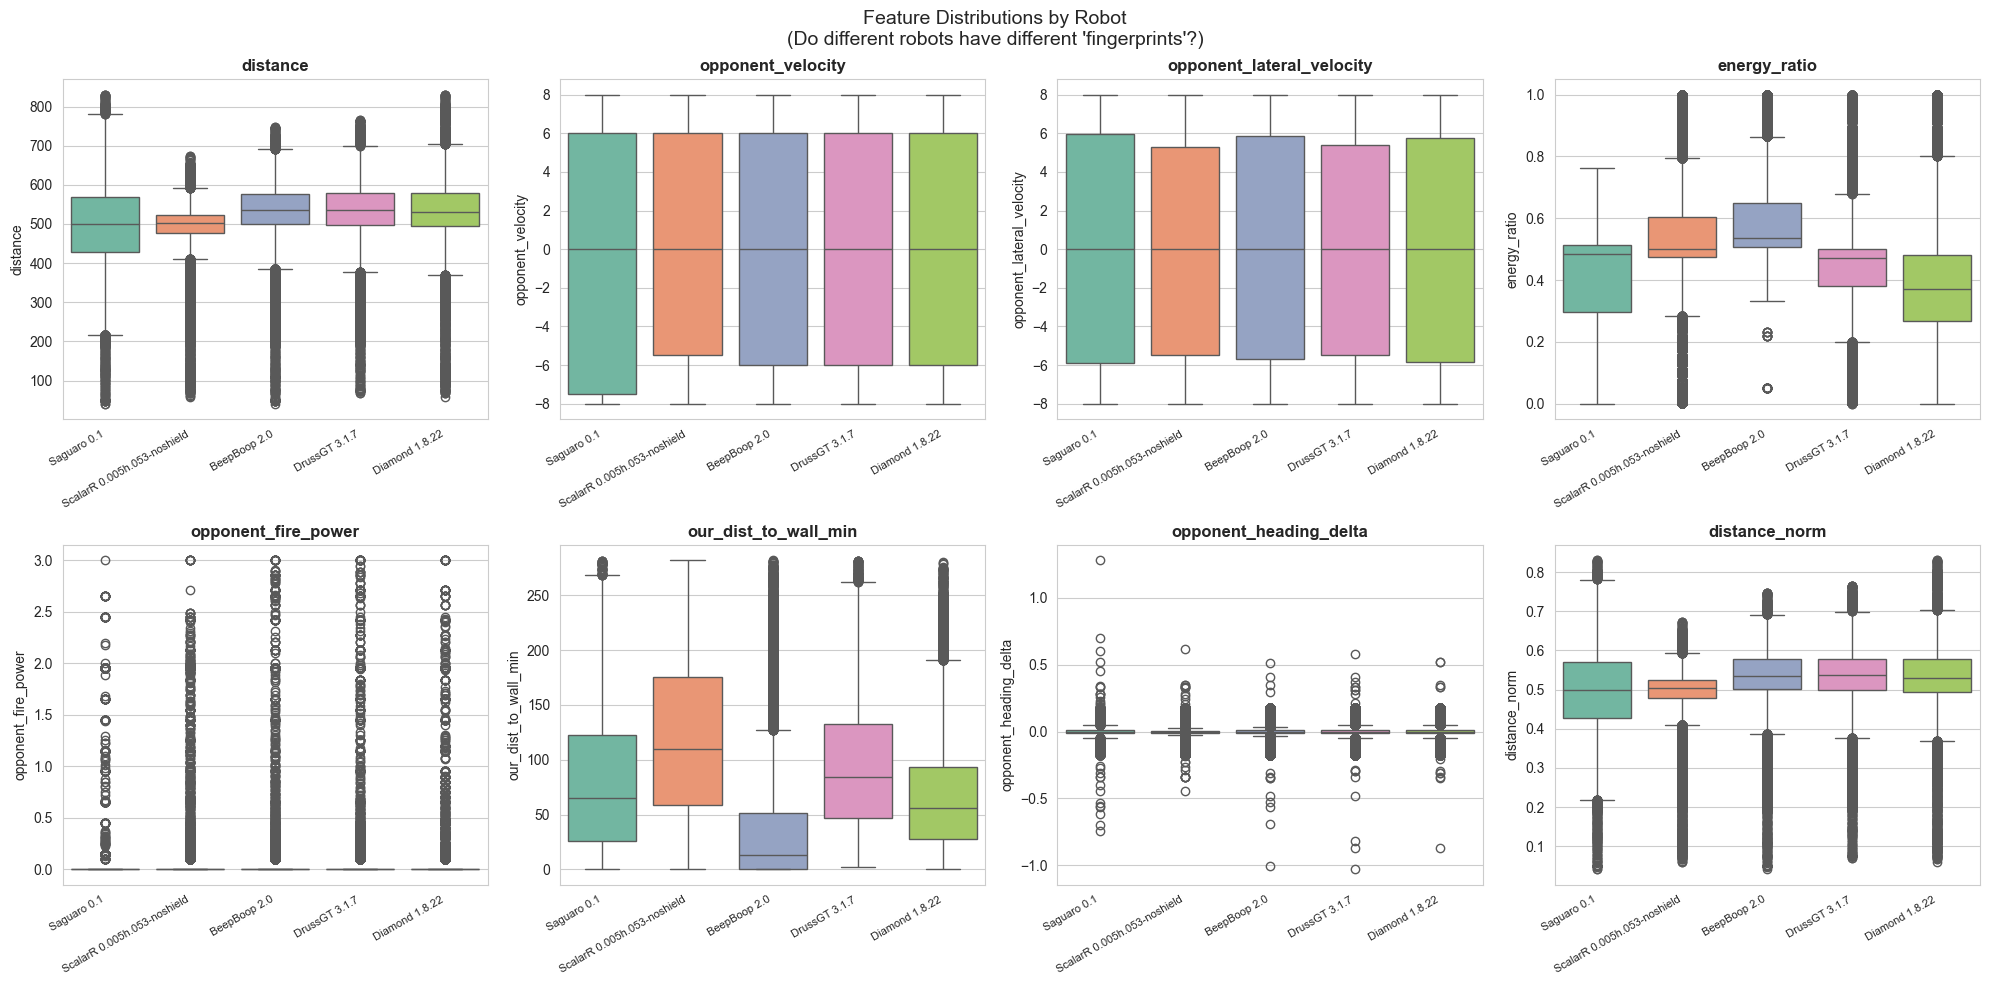

In [7]:
# --- Box plots of key features grouped by robot ---
key_features = ['distance', 'opponent_velocity', 'opponent_lateral_velocity', 
                'energy_ratio', 'opponent_fire_power', 'our_dist_to_wall_min',
                'opponent_heading_delta', 'distance_norm']

# Only keep features that exist in the data
key_features = [f for f in key_features if f in ticks.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    if i >= len(axes):
        break
    ax = axes[i]
    data = ticks[['robot_name', col]].dropna()
    if len(data) > 0:
        sns.boxplot(data=data, x='robot_name', y=col, ax=ax, palette='Set2')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Robot\n(Do different robots have different 'fingerprints'?)", 
             fontsize=14)
plt.tight_layout()
plt.show()

## Section 6 — Time-Series: How a Battle Unfolds

Let's pick one battle and plot features over time. This shows the *dynamics* — how distance, energy, and other features change tick by tick.

Round boundaries are marked with vertical dashed lines.

Battle: 0a24decd
Robots: ['Saguaro 0.1' 'ScalarR 0.005h.053-noshield']


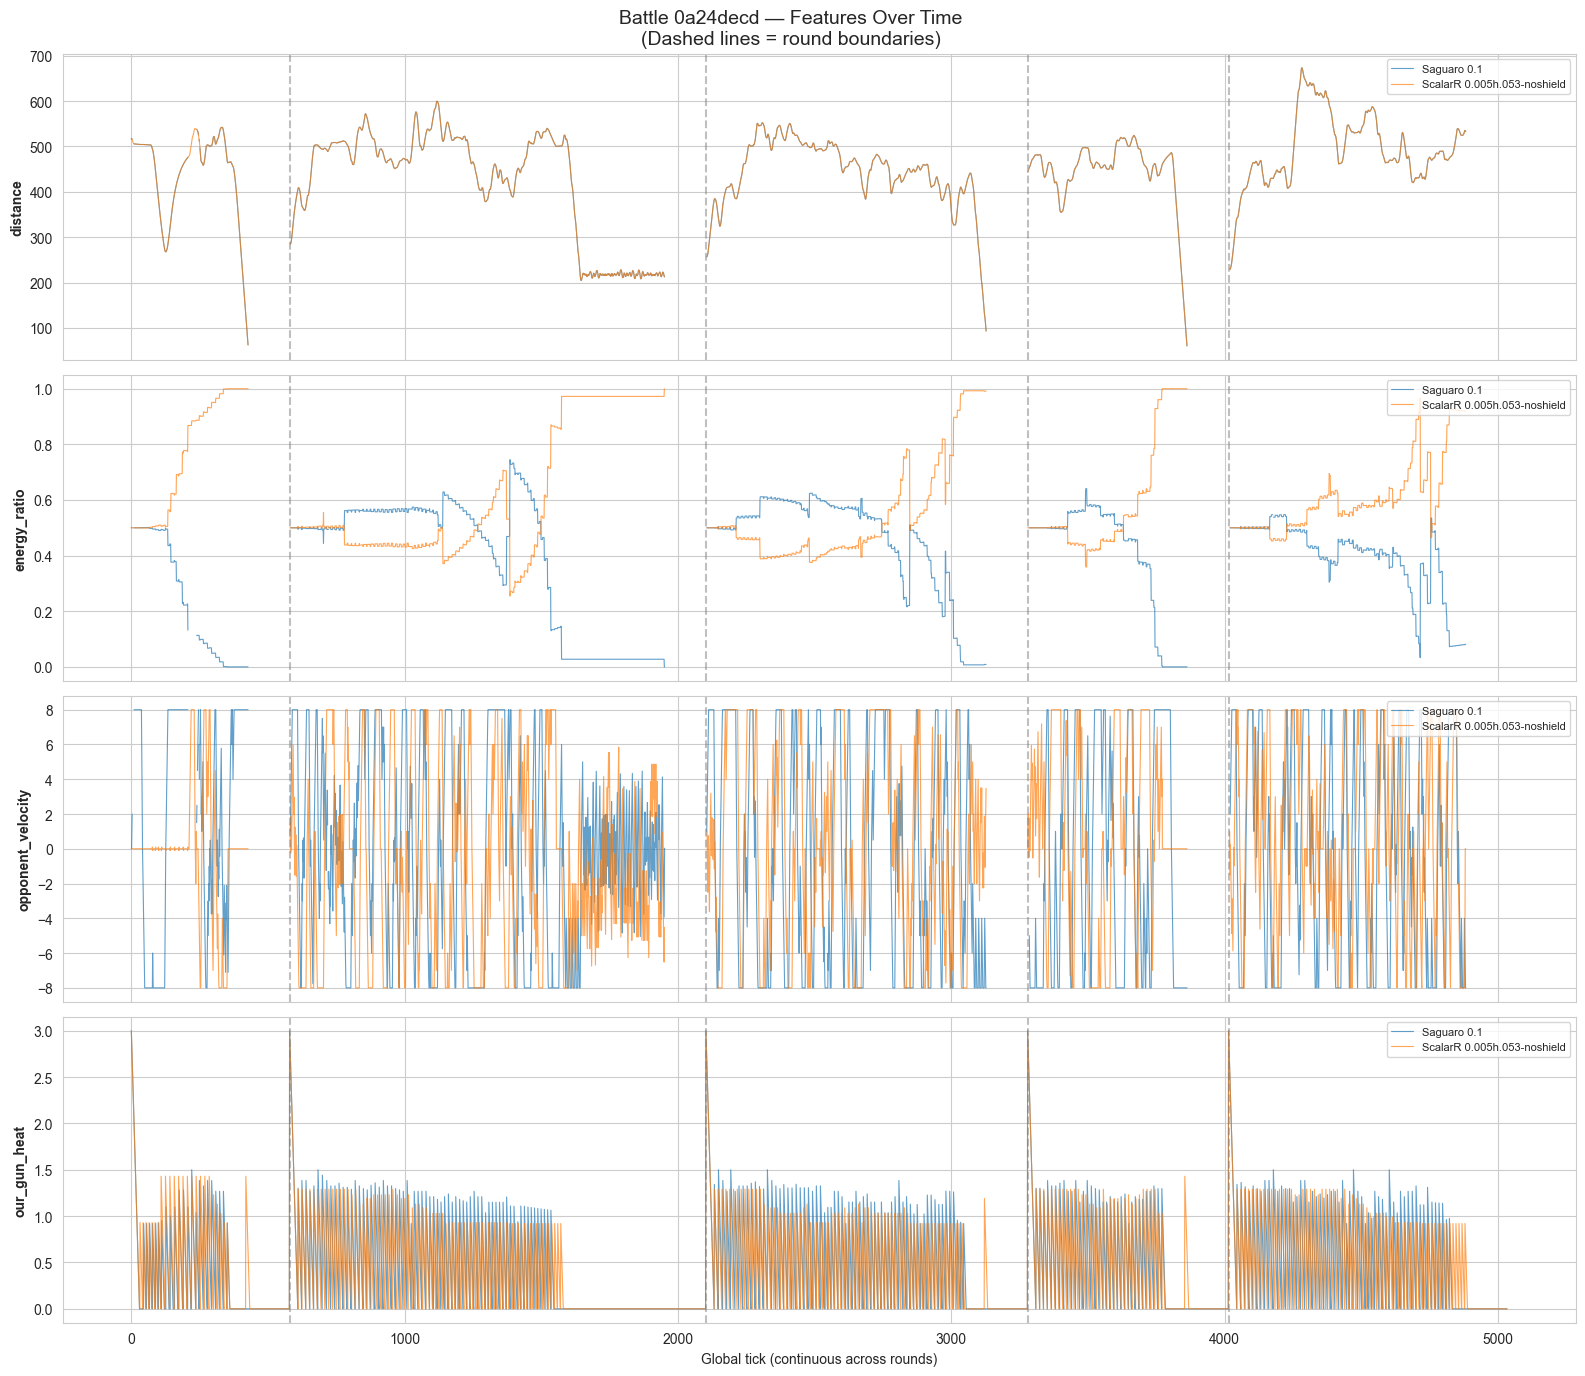

In [8]:
# --- Time series of one battle ---
# Pick the first battle_id
first_battle = ticks['battle_id'].unique()[0]
battle_data = ticks[ticks['battle_id'] == first_battle].copy()
robots_in_battle = battle_data['robot_name'].unique()

print(f"Battle: {first_battle}")
print(f"Robots: {robots_in_battle}")

# Create a continuous tick index (tick resets each round, so we make a global index)
battle_data = battle_data.sort_values(['robot_name', 'round', 'tick'])
battle_data['global_tick'] = battle_data.groupby('robot_name').cumcount()

time_features = ['distance', 'energy_ratio', 'opponent_velocity', 'our_gun_heat']
time_features = [f for f in time_features if f in battle_data.columns]

fig, axes = plt.subplots(len(time_features), 1, figsize=(16, 3.5 * len(time_features)), sharex=True)
if len(time_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, time_features):
    for robot in robots_in_battle:
        rdata = battle_data[battle_data['robot_name'] == robot]
        ax.plot(rdata['global_tick'], rdata[feat], label=robot, alpha=0.7, linewidth=0.8)
    
    # Mark round boundaries
    for robot in robots_in_battle[:1]:  # Use first robot for boundaries
        rdata = battle_data[battle_data['robot_name'] == robot]
        round_starts = rdata.groupby('round')['global_tick'].min()
        for rs in round_starts.values[1:]:  # Skip first round start
            ax.axvline(x=rs, color='gray', linestyle='--', alpha=0.5)
    
    ax.set_ylabel(feat, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Global tick (continuous across rounds)")
fig.suptitle(f"Battle {first_battle} — Features Over Time\n(Dashed lines = round boundaries)", fontsize=14)
plt.tight_layout()
plt.show()

## Section 7 — Waves & Scores Overview

Quick look at bullet patterns and round outcomes.

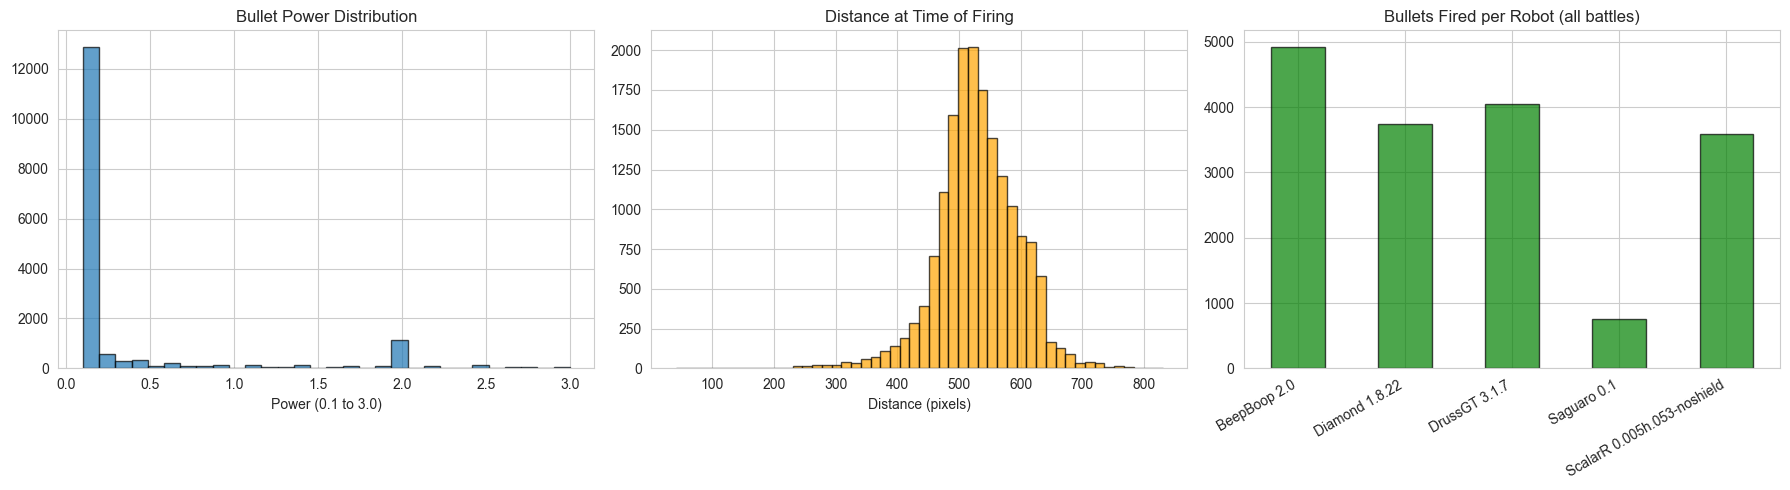

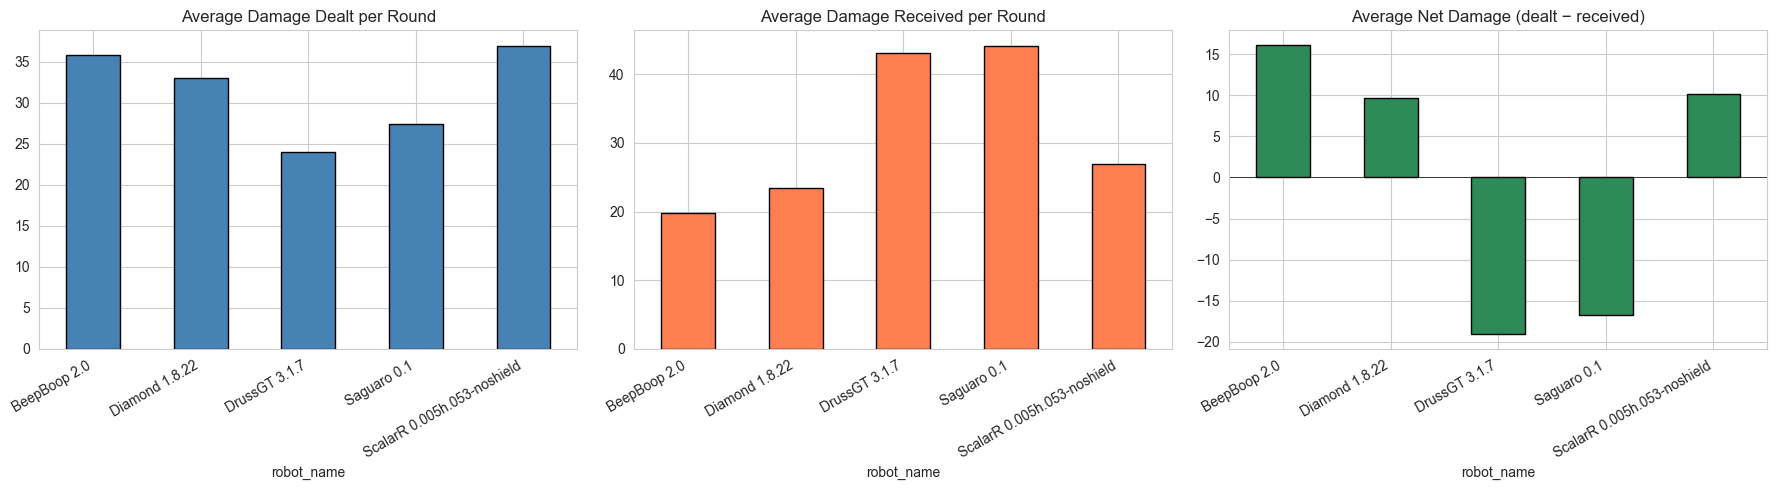

In [9]:
# --- Waves analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bullet power distribution
if 'wave_bullet_power' in waves.columns:
    axes[0].hist(waves['wave_bullet_power'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title("Bullet Power Distribution")
    axes[0].set_xlabel("Power (0.1 to 3.0)")

# Fire distance distribution
if 'wave_fire_distance' in waves.columns:
    axes[1].hist(waves['wave_fire_distance'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title("Distance at Time of Firing")
    axes[1].set_xlabel("Distance (pixels)")

# Waves per robot  
wave_counts = waves.groupby('robot_name').size()
wave_counts.plot.bar(ax=axes[2], color='green', edgecolor='black', alpha=0.7)
axes[2].set_title("Bullets Fired per Robot (all battles)")
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# --- Scores analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Damage dealt per robot
scores.groupby('robot_name')['damage_dealt'].mean().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Average Damage Dealt per Round")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Damage received per robot
scores.groupby('robot_name')['damage_received'].mean().plot.bar(
    ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title("Average Damage Received per Round")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

# Net damage (positive = winning)
scores.groupby('robot_name')['net_damage'].mean().plot.bar(
    ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title("Average Net Damage (dealt − received)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()